<img src="https://dauphine.psl.eu/fileadmin/_processed_/9/2/csm_damier_logo_Dauphine_f7b37a1ff2.jpg" width="200" style="vertical-align:middle" /> <h1>Master 222: Introduction to Python - Session 5</h1>





[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zaltarba/PSL_python_for_finance/blob/main/python_session_5.ipynb)

# Introduction to yfinance

### What is yfinance?

`yfinance` stands for Yahoo Finance, and the `yfinance` library in Python allows you to access financial data from Yahoo! Finance. This can include stock prices, historical data, financial statements, and much more.

### Why use `yfinance`?

If you're interested in financial analysis, algorithmic trading, or just want to understand how the stock market behaves over time, `yfinance` is a great tool to start with. With just a few lines of Python code, you can retrieve vast amounts of financial data.

### Getting Started

Start by importing the library:
```
import yfinance as yf
```
Fetching Data:

You can fetch data for a specific stock or index. Here's how to get the historical data for Apple Inc. (AAPL) for the past month:
```
data = yf.download("AAPL", period="1mo")
print(data)
```

- Fetch the data for AAPL
- Using matplotlib.pyplot, plot the closing prices



In [4]:
import yfinance as yf
import matplotlib.pyplot as plt


/tmp/ipykernel_719/1839859804.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download('AAPL', period='1y')
[*********************100%***********************]  1 of 1 completed


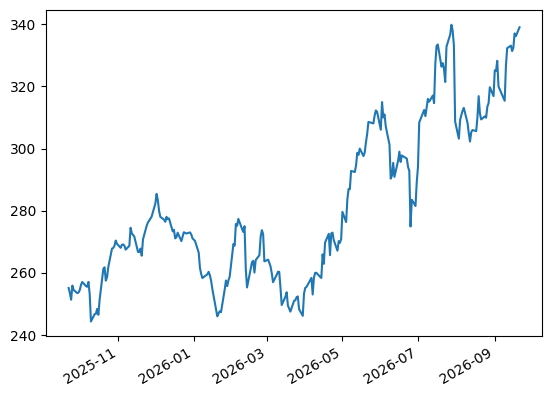

In [5]:
data=yf.download('AAPL', period='1y')
plt.plot(data['Close'])
plt.gcf().autofmt_xdate()
plt.show()

**Exercise: Analyzing Historical Stock Prices**
> Context:
You are a financial analyst at an investment firm. You have been given a dataset containing historical stock prices of several companies over the past decade. Your task is to clean, analyze, and visualize the data to help the firm make informed investment decisions.

> Dataset:
The dataset contains the following columns: 'Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume'.


**Data Loading and Inspection**:

- Fetch the historical stock price data for 'AAPL'.
- Display the first 10 rows of the dataset.
- Check for any missing values in the dataset.

**Data Cleaning**:

- Handle any missing values: You can either fill them using methods such as forward fill, backward fill, or interpolation, or you can choose to drop rows with missing values.
- Convert the 'Date' column to a datetime format if it isn't already..

**Data Transformation**:

- Make the 'Date' column the index of the DataFrame to facilitate time series analysis.
- Compute a new column 'Price_Average', which is the arithmetic mean of the 'High' and 'Low' prices for each trading day.

**Data Analysis**:

- Determine the specific date when the trading volume for Apple Inc. was at its peak.
- Compute the monthly average of the 'Close' price to understand monthly performance trends.

**Data Aggregation**:

- Calculate the total trading volume and average closing price for each company over the period.

**File I/O**:

- Save the cleaned and transformed dataset to a new CSV file.
- Save the plots as image files.

**Bonus**:

- Use a simple linear regression model to attempt predictions of future stock prices based on historical data. This will provide a rudimentary forecast which can be enhanced with more complex models.
- Implement a basic moving average trading strategy. For instance, consider using a 50-day and a 200-day moving average. Generate buy signals when the 50-day moving average crosses above the 200-day moving average, and sell signals when it crosses below. Backtest this strategy to gauge its historical performance.

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
tickers=['AAPL','MSFT','TSLA','NVO','MC.PA','OR.PA','NVDA','BNP.PA','TTE.PA']
data=yf.download(tickers,period='10y')
data.head(10)

/tmp/ipykernel_719/4008341938.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(tickers,period='10y')
[*********************100%***********************]  9 of 9 completed


Price           Close                                                         \
Ticker           AAPL     BNP.PA       MC.PA       MSFT      NVDA        NVO   
Date                                                                           
2016-09-22  26.211948  27.494654  129.032806  51.342270  1.595125  18.039003   
2016-09-23  25.775162  27.294119  128.656250  50.995953  1.593408  17.765862   
2016-09-26  25.814032  26.401844  126.982658  50.525352  1.578443  17.587732   
2016-09-27  25.862055  26.265247  127.066353  51.457703  1.632416  17.358131   
2016-09-28  26.058737  26.515198  127.526558  51.528740  1.638304  17.314590   
2016-09-29  25.653957  26.393124  126.104027  50.969318  1.653514  16.546637   
2016-09-30  25.852911  26.605291  127.024544  51.146900  1.680991  16.463507   
2016-10-03  25.731705  26.515198  127.191864  50.987072  1.679273  16.277458   
2016-10-04  25.841478  26.756424  131.041077  50.827244  1.675593  16.083490   
2016-10-05  25.852911  27.669037  130.748169  51.182438  1.673876  16.435801   

Price                                              High  ...       Open  \
Ticker           OR.PA       TSLA     TTE.PA       AAPL  ...     TTE.PA   
Date                                                     ...              
2016-09-22  144.866974  13.762000  23.901093  26.285128  ...  23.265469   
2016-09-23  144.269424  13.830000  23.612432  26.250828  ...  23.798400   
2016-09-26  142.263275  13.932667  23.165550  25.930662  ...  23.373724   
2016-09-27  143.031631  13.720667  22.968382  25.882637  ...  23.362738   
2016-09-28  143.799911  13.751333  23.081049  26.216531  ...  23.097949   
2016-09-29  143.116989  13.380000  24.038759  26.024429  ...  24.210586   
2016-09-30  143.501129  13.602000  23.757088  25.926090  ...  23.678217   
2016-10-03  143.629166  14.246667  23.844398  25.852910  ...  23.802146   
2016-10-04  145.421875  14.094000  24.286644  26.141056  ...  23.886656   
2016-10-05  141.879166  13.897333  24.264112  25.992409  ...  23.990880   

Price            Volume                                                 \
Ticker             AAPL     BNP.PA      MC.PA        MSFT         NVDA   
Date                                                                     
2016-09-22  124296000.0  5030250.0   845731.0  19822200.0  308732000.0   
2016-09-23  209924800.0  3697080.0   534423.0  19955300.0  276132000.0   
2016-09-26  119477600.0  3919481.0   524416.0  21688700.0  230040000.0   
2016-09-27   98429600.0  4208318.0   577866.0  28065100.0  402752000.0   
2016-09-28  118564400.0  3447639.0   435720.0  20536400.0  319788000.0   
2016-09-29  143548000.0  2463934.0   479949.0  25463500.0  336684000.0   
2016-09-30  145516400.0  6379925.0   743922.0  29910800.0  429932000.0   
2016-10-03   86807200.0  1773168.0   324385.0  19189500.0  242596000.0   
2016-10-04  118947200.0  2739790.0  1109267.0  20085900.0  281624000.0   
2016-10-05   85812400.0  5192510.0   614540.0  16726400.0  305440000.0   

Price                                                    
Ticker             NVO     OR.PA        TSLA     TTE.PA  
Date                                                     
2016-09-22   4693000.0  665852.0  35743500.0  7651893.0  
2016-09-23   7747800.0  353632.0  43578000.0  5818834.0  
2016-09-26   3881400.0  456439.0  35916000.0  6268784.0  
2016-09-27   6298400.0  433051.0  50598000.0  6137801.0  
2016-09-28   5844600.0  382823.0  31326000.0  4402576.0  
2016-09-29   9584200.0  354474.0  40905000.0  7934813.0  
2016-09-30  11301000.0  580712.0  38794500.0  7665326.0  
2016-10-03   7161800.0  343323.0  89998500.0  4144437.0  
2016-10-04  10758800.0  549128.0  53122500.0  5844520.0  
2016-10-05  10034000.0  487257.0  28162500.0  5933056.0  

[10 rows x 45 columns]

In [8]:
data['Close'].isna().sum()

,0
Ticker,
AAPL,72
BNP.PA,24
MC.PA,24
MSFT,72
NVDA,72
NVO,72
OR.PA,24
TSLA,72
TTE.PA,24


In [9]:
data=data.ffill()
data.isna().any()

Price   Ticker
Close   AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
High    AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
Low     AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
Open    AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
Volume  AAPL      False
        BNP.PA    False
        MC.PA     False
        MSFT      False
        NVDA      False
        NVO       False
        OR.PA     False
        TSLA      False
        TTE.PA    False
dtype: bool

In [10]:
print(data.index.dtype)

datetime64[ns]


In [11]:
price_average=(data['High']+data['Low'])/2
price_average.head(10)

Ticker,AAPL,BNP.PA,MC.PA,MSFT,NVDA,NVO,OR.PA,TSLA,TTE.PA
Date,,,,,,,,,
2016-09-22,26.177645,27.276673,128.300616,51.337831,1.595739,18.076609,143.906601,13.676000,23.644345
2016-09-23,25.880358,27.301383,128.258777,51.186866,1.594022,17.742110,144.504184,13.861667,23.704029
2016-09-26,25.720271,26.673595,127.275533,50.600829,1.571697,17.641173,142.775479,13.916667,23.194695
2016-09-27,25.786589,26.287045,127.066346,50.942682,1.603222,17.275003,143.223698,13.819667,23.109222
2016-09-28,26.078176,26.571873,128.028636,51.382226,1.628490,17.300735,143.991991,13.783667,23.162736
2016-09-29,25.795743,26.605293,127.526571,51.226826,1.639530,16.734667,143.885289,13.597000,24.106363
2016-09-30,25.746572,25.891767,125.622920,51.106943,1.675103,16.453611,142.327339,13.484333,23.666951
2016-10-03,25.764865,26.483226,126.773470,50.884958,1.690804,16.225998,143.479772,14.130667,23.937353
2016-10-04,25.948960,26.728814,129.095533,50.867201,1.686510,16.075572,144.717591,14.071333,24.096508


In [12]:
max_volume_date=data['Volume'].idxmax()
max_volume_date

,0
Ticker,
AAPL,2017-02-01
BNP.PA,2020-03-12
MC.PA,2020-03-12
MSFT,2026-06-26
NVDA,2017-06-09
NVO,2025-07-29
OR.PA,2020-03-12
TSLA,2020-02-04
TTE.PA,2020-03-09


In [13]:
monthly_close_mean = data['Close'].resample('ME').mean()
monthly_volume_sum = data['Volume'].resample('ME').sum()

monthly_data = pd.concat([monthly_close_mean, monthly_volume_sum], axis=1, keys=['Close', 'Volume'])
monthly_data.head(10)

Close                                                         \
Ticker           AAPL     BNP.PA       MC.PA       MSFT      NVDA        NVO   
Date                                                                           
2016-09-30  25.889829  26.709925  127.484742  51.138034  1.624600  17.296495   
2016-10-31  26.460562  28.993949  136.647568  51.855174  1.672054  15.862189   
2016-11-30  25.319371  31.426238  138.777065  53.428437  2.049397  13.182431   
2016-12-31  26.281181  34.651625  149.408170  55.531464  2.447972  13.975480   
2017-01-31  27.439613  35.417271  156.459727  56.428758  2.592369  14.178179   
2017-02-28  30.853045  33.087173  158.853171  57.530256  2.711209  13.801993   
2017-03-31  32.462516  35.041470  167.610770  58.317339  2.554728  13.516513   
2017-04-30  32.986332  35.680334  179.272022  59.513770  2.488233  14.661186   
2017-05-31  35.252134  38.495617  196.625910  62.209563  3.100068  16.489456   
2017-06-30  34.268674  38.104816  195.046079  63.786574  3.724074  17.519582   

                                                    Volume               \
Ticker           OR.PA       TSLA     TTE.PA          AAPL       BNP.PA   
Date                                                                      
2016-09-30  143.549905  13.711238  23.503479  9.597568e+08   29146627.0   
2016-10-31  141.702332  13.445555  24.651489  2.747657e+09   93386518.0   
2016-11-30  137.203400  12.622576  24.452836  2.995926e+09   87049992.0   
2016-12-31  142.903551  13.370190  26.677154  2.435087e+09   85733922.0   
2017-01-31  145.765276  15.872273  27.461778  2.479281e+09   66098503.0   
2017-02-28  147.837737  17.609133  27.105309  2.388667e+09   73510271.0   
2017-03-31  151.521863  17.210435  26.952897  2.246514e+09   91362982.0   
2017-04-30  155.286477  20.317228  27.616426  1.493216e+09  102736480.0   
2017-05-31  163.432622  21.126580  27.642046  2.703638e+09  117038933.0   
2017-06-30  164.718414  24.386909  26.321373  2.736712e+09   92500449.0   

                                                                            \
Ticker           MC.PA         MSFT          NVDA          NVO       OR.PA   
Date                                                                         
2016-09-30   4142027.0  165442000.0  2.304060e+09   49350400.0   3226983.0   
2016-10-31  15023241.0  614841800.0  6.551568e+09  184098000.0  10659442.0   
2016-11-30  15045398.0  634905700.0  1.321070e+10  239742400.0  14286733.0   
2016-12-31  14366421.0  513579700.0  1.808223e+10  128372000.0  11706749.0   
2017-01-31  15828892.0  538455700.0  1.506759e+10  102925200.0  11769189.0   
2017-02-28  10836338.0  461992800.0  1.477053e+10  118731200.0  13553994.0   
2017-03-31  12553357.0  489169700.0  1.428896e+10   91159600.0  12911497.0   
2017-04-30  14670200.0  433191200.0  9.572572e+09  100472000.0  12421918.0   
2017-05-31  14369920.0  537046400.0  1.998858e+10  104723400.0  12948644.0   
2017-06-30  13960285.0  629716800.0  2.344552e+10   84283000.0  13557582.0   

                                       
Ticker              TSLA       TTE.PA  
Date                                   
2016-09-30  2.768610e+08   45880027.0  
2016-10-31  1.381992e+09  108745177.0  
2016-11-30  1.556668e+09  120295896.0  
2016-12-31  1.319901e+09  133886479.0  
2017-01-31  1.671228e+09   98979744.0  
2017-02-28  1.886956e+09   96148800.0  
2017-03-31  1.605530e+09  133095815.0  
2017-04-30  1.754259e+09  124176400.0  
2017-05-31  2.337728e+09  135430985.0  
2017-06-30  2.789266e+09  141750841.0

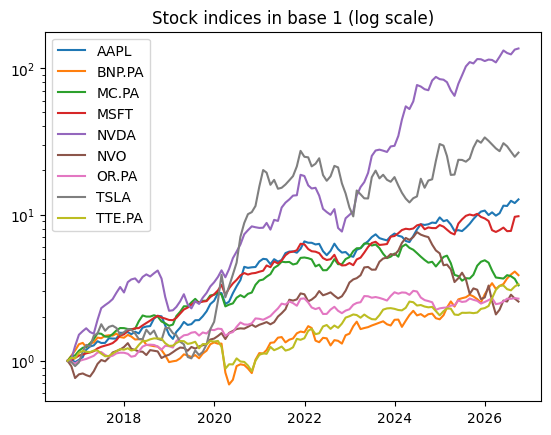

In [14]:
monthly_prices_rebased=monthly_data['Close']/monthly_data['Close'].iloc[0]
plt.plot(monthly_prices_rebased)
plt.title('Stock indices in base 1 (log scale)')
plt.legend(monthly_prices_rebased.columns)
plt.yscale('log')
plt.savefig("stock_prices.png", dpi=300, bbox_inches="tight")
plt.show()

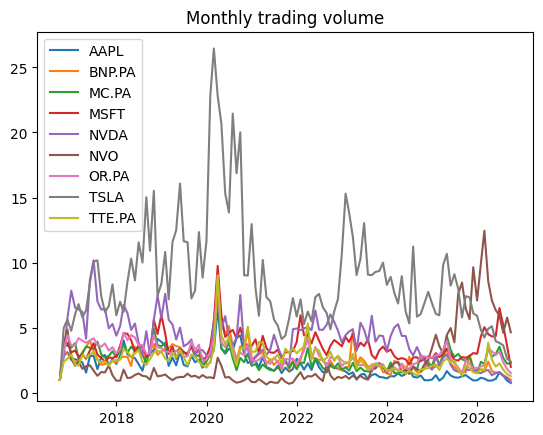

In [15]:
monthly_volume_rebased=monthly_data['Volume']/monthly_data['Volume'].iloc[0]
plt.plot(monthly_volume_rebased)
plt.title('Monthly trading volume')
plt.legend(monthly_volume_rebased.columns)
plt.savefig("monthly_volume.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
data.to_csv('clean_data.csv', index='False')

**Exercice TO DO: Momentum Strategy on 50 Stocks**

## Objective
Explore the performance of a simple momentum strategy on a subset of 50 stocks.

## Procedure

### 1. Stock Selection
- Use `pandas` to fetch the list of all tickers from [this link](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies)
    - Use pd.read_html
- Randomly select 50 stocks from this list.

### 2. Data Collection
- For each stock, download the daily adjusted closing prices for the last 365 days.
- Store this data in a pandas DataFrame with dates as the index.

### 3. Momentum Calculation
- Define momentum as the percentage change in the stock price over the previous n days (e.g., n=21 for a month).
- Using pandas, compute the momentum for each stock for each day.
- Rank the stocks based on their momentum every day.

### 4. Strategy

1. At the beginning of each month, buy the top 10 stocks based on momentum from the previous month.
2. At the end of the month, sell all the stocks.
3. Repeat this process for each month in your dataset.

### 5. Performance Analysis

- Calculate the monthly and annualized return of this strategy.
- Compare the strategy's performance against a benchmark (e.g., S&P 500).
- Plot the cumulative returns of your strategy and the benchmark.

### 6. Risk Analysis
- Using numpy, compute the standard deviation of the monthly returns to get a measure of the strategy's risk.
- Calculate the Sharpe Ratio.

## Hints

- To get the tickers list:
```python
import requests

# URL of the Wikipedia page
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

# Set headers to mimic a browser
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Send the HTTP request with custom headers
response = requests.get(url, headers=headers)

# Use pandas to read the HTML from the response content
tables = pd.read_html(response.text)
```

In [17]:
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": "Mozilla/5.0"
}
response = requests.get(url, headers=headers)
tables = pd.read_html(response.text)

/tmp/ipykernel_719/2158521338.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [18]:
tickers=tables[0]['Symbol'].to_list()
tickers_subset=np.random.choice(tickers,50,replace='False')
print(tickers_subset)

['FDXF' 'KIM' 'ALL' 'P' 'HOOD' 'MPWR' 'DELL' 'APD' 'RVTY' 'BKR' 'MCD'
 'TRMB' 'LOW' 'URI' 'PKG' 'CSX' 'NTAP' 'TPR' 'DGX' 'SWK' 'PTC' 'TMO'
 'MPWR' 'ROST' 'JBL' 'STT' 'HONA' 'ORLY' 'MAR' 'TFC' 'NCLH' 'MMM' 'LOW'
 'DVA' 'DVN' 'JCI' 'WM' 'IR' 'F' 'EXC' 'EQT' 'PHM' 'BBY' 'ON' 'NOC' 'BMY'
 'LITE' 'GOOG' 'IBKR' 'MRSH']


In [19]:
data=yf.download(list(tickers_subset),period="365d")
prices=data['Close']
prices.head(10)

/tmp/ipykernel_719/1528857089.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(list(tickers_subset),period="365d")
[*********************100%***********************]  48 of 48 completed


Ticker,ALL,APD,BBY,BKR,BMY,CSX,DELL,DGX,DVA,DVN,...,ROST,RVTY,STT,SWK,TFC,TMO,TPR,TRMB,URI,WM
Date,,,,,,,,,,,,,,,,,,,,,
2025-04-08,178.243835,240.619781,51.929085,34.065434,49.980209,26.137800,70.929947,156.333725,143.919998,25.772041,...,125.158745,91.401581,72.914085,52.284538,32.644379,417.034729,59.340061,55.119999,545.045776,211.384537
2025-04-09,187.502380,261.515930,58.844341,37.715309,50.611210,28.067039,82.264664,160.501297,152.860001,29.878260,...,135.120163,100.911148,79.679916,60.109436,35.514324,451.088898,65.881180,61.490002,603.486572,219.147766
2025-04-10,185.355347,253.618149,55.238792,35.681114,47.522167,27.244415,77.134727,160.295868,153.360001,26.685604,...,136.984238,92.626358,76.466393,54.924038,33.317463,425.120605,62.591034,58.040001,572.696045,221.130066
2025-04-11,187.065186,260.364136,55.867451,36.917206,47.757610,27.430485,80.056351,160.432831,155.509995,27.147192,...,139.568283,94.458572,76.863243,55.232918,33.083752,435.772461,62.081852,58.220001,575.619080,223.991257
2025-04-14,189.931152,263.819366,57.097034,36.800407,48.350929,27.685106,83.241814,164.355850,150.880005,27.628016,...,141.688766,97.206886,78.315140,56.253147,33.822273,446.891815,62.453941,59.490002,589.375061,226.842667
2025-04-15,188.998505,256.773376,56.523842,37.141056,47.088943,27.322762,83.534935,163.602539,146.279999,27.435686,...,139.094864,95.135696,78.789421,55.092518,34.112076,438.606995,62.610619,59.590000,589.720642,226.041901
2025-04-16,188.707047,252.921310,55.127857,37.111862,46.486210,26.784142,81.453651,160.902390,141.500000,28.176151,...,136.777100,93.353271,77.076180,53.173733,33.654007,434.419891,61.562862,58.279999,577.919861,224.176819
2025-04-17,189.115082,254.450500,57.291187,37.871029,46.363781,27.107315,82.860733,160.246948,140.029999,29.147409,...,137.714066,91.499763,78.653908,53.548126,33.560524,425.180267,62.316856,58.230000,584.111633,225.485306
2025-04-21,181.624695,249.301483,57.420612,36.790676,46.090664,26.891863,80.505836,158.349014,133.500000,28.349245,...,133.630890,89.456909,78.044106,52.761898,33.008972,419.560944,61.866421,56.220001,563.472595,222.223770


In [20]:
momentum = prices.pct_change(periods=21)
momentum.iloc[20:25]

Ticker,ALL,APD,BBY,BKR,BMY,CSX,DELL,DGX,DVA,DVN,...,ROST,RVTY,STT,SWK,TFC,TMO,TPR,TRMB,URI,WM
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-08,0.104377,0.084590,0.235891,0.042237,-0.116638,0.085050,0.334028,0.100751,-0.002015,0.191418,...,0.129787,0.012849,0.248639,0.107232,0.132875,-0.020343,0.279538,0.222424,0.213900,0.076962
2025-05-09,0.049948,0.003442,0.081697,-0.052392,-0.135653,0.002791,0.146515,0.078630,-0.059532,0.046991,...,0.038540,-0.098893,0.139577,-0.024136,0.040526,-0.111167,0.159483,0.107822,0.100275,0.037118
2025-05-12,0.061324,0.054076,0.227950,0.032649,-0.045184,0.089504,0.318511,0.073543,-0.058229,0.209009,...,0.074663,0.059703,0.215190,0.236026,0.169127,0.012048,0.293179,0.215369,0.227420,-0.003886
2025-05-13,0.051987,0.017211,0.220751,0.012930,-0.081246,0.090325,0.324810,0.064028,-0.074143,0.214666,...,0.055261,0.020264,0.231331,0.250974,0.183972,-0.020997,0.318612,0.223806,0.238549,-0.030517


In [21]:
momentum=momentum.dropna()
momentum.head()

Ticker,ALL,APD,BBY,BKR,BMY,CSX,DELL,DGX,DVA,DVN,...,ROST,RVTY,STT,SWK,TFC,TMO,TPR,TRMB,URI,WM
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-16,0.090393,0.057170,0.116458,-0.094781,0.088070,0.073855,-0.043244,0.039971,0.115661,-0.011486,...,-0.017105,0.110890,0.114800,0.076769,0.098391,0.146648,-0.045036,0.070504,-0.011245,0.116668
2026-07-17,0.120176,0.060526,0.145099,-0.090540,0.098456,0.082090,-0.019155,0.052211,0.133936,0.021917,...,-0.004393,0.088906,0.070748,0.065587,0.068593,0.126632,-0.053083,0.038204,-0.022995,0.094789
2026-07-20,0.144681,0.059353,0.180067,-0.081904,0.100563,0.099627,-0.089287,0.054330,0.111692,0.028182,...,0.010847,0.088803,0.072407,0.060992,0.058750,0.139791,-0.032563,0.088807,-0.034567,0.107482
2026-07-21,0.138219,0.064313,0.140372,-0.034754,0.141070,0.093360,-0.011434,0.065031,0.141263,0.047009,...,0.012929,0.105893,0.094483,0.016599,0.063108,0.126665,-0.009338,0.054719,-0.058757,0.086580
2026-07-22,0.131515,0.055579,0.146033,-0.043111,0.123325,0.080736,0.056889,0.088352,0.106830,0.042509,...,0.005233,0.116815,0.071683,0.034063,0.060911,0.134588,-0.036662,0.017672,-0.052733,0.108153


In [22]:
ranked_momentum = momentum.rank(axis=1, ascending=False)
ranked_momentum.head()

Ticker,ALL,APD,BBY,BKR,BMY,CSX,DELL,DGX,DVA,DVN,...,ROST,RVTY,STT,SWK,TFC,TMO,TPR,TRMB,URI,WM
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-16,11.0,17.0,3.0,44.0,12.0,15.0,36.0,20.0,4.0,28.0,...,29.0,6.0,5.0,14.0,9.0,1.0,39.0,16.0,27.0,2.0
2026-07-17,4.0,13.0,1.0,43.0,5.0,9.0,28.0,15.0,2.0,20.0,...,24.0,8.0,10.0,12.0,11.0,3.0,36.0,18.0,29.0,6.0
2026-07-20,2.0,15.0,1.0,43.0,7.0,8.0,44.0,17.0,4.0,20.0,...,21.0,10.0,11.0,14.0,16.0,3.0,30.0,9.0,31.0,6.0
2026-07-21,4.0,13.0,3.0,37.0,2.0,9.0,29.0,12.0,1.0,18.0,...,24.0,7.0,8.0,21.0,15.0,5.0,28.0,16.0,41.0,10.0
2026-07-22,3.0,16.0,1.0,41.0,4.0,10.0,15.0,9.0,7.0,19.0,...,28.0,5.0,12.0,22.0,13.0,2.0,37.0,24.0,42.0,6.0


In [23]:
monthly_rank=ranked_momentum.resample('MS').first()
monthly_rank.head()

Ticker,ALL,APD,BBY,BKR,BMY,CSX,DELL,DGX,DVA,DVN,...,ROST,RVTY,STT,SWK,TFC,TMO,TPR,TRMB,URI,WM
Date,,,,,,,,,,,,,,,,,,,,,
2026-07-01,11.0,17.0,3.0,44.0,12.0,15.0,36.0,20.0,4.0,28.0,...,29.0,6.0,5.0,14.0,9.0,1.0,39.0,16.0,27.0,2.0
2026-08-01,22.0,43.0,10.0,3.0,4.0,26.0,11.0,16.0,34.0,8.0,...,2.0,30.0,18.0,20.0,27.0,9.0,17.0,12.0,29.0,36.0
2026-09-01,19.0,9.0,26.0,7.0,13.0,20.0,18.0,15.0,47.0,4.0,...,40.0,5.0,12.0,29.0,30.0,8.0,45.0,14.0,43.0,24.0


In [24]:
top10_tickers=monthly_rank.apply(lambda row:row.nsmallest(10).index.tolist(),axis=1)
top10_tickers.head()

,0
Date,
2026-07-01,"[TMO, WM, BBY, DVA, STT, RVTY, PTC, IR, TFC, M..."
2026-08-01,"[NTAP, ROST, BKR, BMY, PTC, MMM, P, DVN, TMO, ..."
2026-09-01,"[P, HOOD, LITE, DVN, RVTY, PTC, BKR, TMO, APD,..."
